# Problem Statement



<html> <font color = Darkblue>
The purpose is to predict whether the Pima Indian women shows signs of diabetes or not. We are using a dataset collected by "National Institute of Diabetes and Digestive and Kidney Diseases" which consists of a number of attributes which would help us to perform this prediction.
</font>
</html>

<html>
<font color = blue>
<b>Constraints on data collection </b>

</font>
</html>

<html> <font color = Darkblue>
All patients whose data has been collected are females at least 21 years old of Pima Indian heritage
</font>
</html>

In [2]:
#Import all the necessary modules
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split

from sklearn import metrics
from sklearn.metrics import accuracy_score, confusion_matrix, recall_score, precision_score, f1_score, auc
from sklearn.metrics import roc_curve, auc

# Q1. Load the PIMA Indian Diabetes file into Python DataFrame. 


The file can be accessed directly from the URL (https://archive.ics.uci.edu/ml/machine-learning-databases/pima-indians-diabetes/pima-indians-diabetes.data or you may first download it to a local folder and then load it into Python dataframe.  Let us assume the data frame is named pima_df


In [3]:
colnames = ['preg', 'plasma', 'BP', 'thick', 'insulin', 'BMI', 'pedi', 'age', 'outcome']
pima_df = pd.read_csv( 'pima-indians-diabetes.data',names= colnames )

It is always a good practice to eye-ball raw data to get a feel of the data in terms of number of structure of the file, number of attributes, types of attributes and a general idea of likely challenges in the dataset. You would notice that it is a comma separated file. There are no column names!. Check the associated folders and find out about each attribute the name. What information is available about the data.

# Q2. Print 10 samples from the dataset

In [4]:
pima_df.head(10)

,preg,plasma,BP,thick,insulin,BMI,pedi,age,outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1
5,5,116,74,0,0,25.6,0.201,30,0
6,3,78,50,32,88,31.0,0.248,26,1
7,10,115,0,0,0,35.3,0.134,29,0
8,2,197,70,45,543,30.5,0.158,53,1
9,8,125,96,0,0,0.0,0.232,54,1


# Q3 Print the datatypes of each column and the shape of the dataset 

In [5]:
pima_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
preg       768 non-null int64
plasma     768 non-null int64
BP         768 non-null int64
thick      768 non-null int64
insulin    768 non-null int64
BMI        768 non-null float64
pedi       768 non-null float64
age        768 non-null int64
outcome    768 non-null int64
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [6]:
pima_df.shape

(768, 9)

There are '0's in the data. Are they really valid '0's or they are missing values?
Plasma, BP, skin thickness etc. these values cannot be 0.
look at column by column logically to understand this.


# Q4 Replace all the 0s in the column with the median of the same column value accordingly.

In [7]:
# Replace 0 with NaN

pima_df["plasma"].replace(0, np.nan, inplace= True)
pima_df["BP"].replace(0, np.nan, inplace= True)
pima_df["thick"].replace(0, np.nan, inplace= True)
pima_df["insulin"].replace(0, np.nan, inplace= True)
pima_df["BMI"].replace(0, np.nan, inplace= True)
pima_df.head(10)

,preg,plasma,BP,thick,insulin,BMI,pedi,age,outcome
0,6,148.0,72.0,35.0,NaN,33.6,0.627,50,1
1,1,85.0,66.0,29.0,NaN,26.6,0.351,31,0
2,8,183.0,64.0,NaN,NaN,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,NaN,NaN,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,NaN,NaN,NaN,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,NaN,NaN,NaN,0.232,54,1


In [9]:
# Replace NaN with Median

pima_df.fillna(pima_df.median(),inplace = True)
pima_df.head(10)

,preg,plasma,BP,thick,insulin,BMI,pedi,age,outcome
0,6,148.0,72.0,35.0,125.0,33.6,0.627,50,1
1,1,85.0,66.0,29.0,125.0,26.6,0.351,31,0
2,8,183.0,64.0,29.0,125.0,23.3,0.672,32,1
3,1,89.0,66.0,23.0,94.0,28.1,0.167,21,0
4,0,137.0,40.0,35.0,168.0,43.1,2.288,33,1
5,5,116.0,74.0,29.0,125.0,25.6,0.201,30,0
6,3,78.0,50.0,32.0,88.0,31.0,0.248,26,1
7,10,115.0,72.0,29.0,125.0,35.3,0.134,29,0
8,2,197.0,70.0,45.0,543.0,30.5,0.158,53,1
9,8,125.0,96.0,29.0,125.0,32.3,0.232,54,1


# Q5 Print the descriptive statistics of each & every column using describe() function

In [29]:
pima_df.describe()

,preg,plasma,BP,thick,insulin,BMI,pedi,age,outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,120.894531,69.105469,20.536458,79.799479,31.992578,0.471876,33.240885,0.348958
std,3.369578,31.972618,19.355807,15.952218,115.244002,7.884160,0.331329,11.760232,0.476951
min,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.078000,21.000000,0.000000
25%,1.000000,99.000000,62.000000,0.000000,0.000000,27.300000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,23.000000,30.500000,32.000000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,127.250000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


# Q6 See the distribution of 'Class' variable and plot it using appropriate graph.

[]

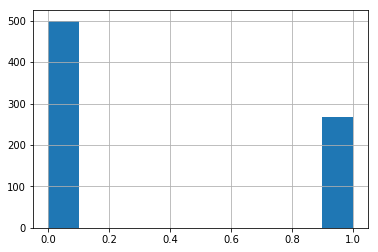

In [94]:
# Univariate Analysis of Class or Outcome variable
import matplotlib.pyplot as plt 
pima_df.outcome.value_counts()
pima_df.outcome.hist()
plt.plot()


#Just for your understanding - Using univariate analysis check the individual attributes for their basic statistic such as central values, spread, tails etc. What are your observations (any two attributes). Its an optional step and will not be graded.

In [107]:
pima_df.groupby(["outcome"]).count().T

outcome,0,1
preg,500,268
plasma,500,268
BP,500,268
thick,500,268
insulin,500,268
BMI,500,268
pedi,500,268
age,500,268


# Q7. Use pairplots and correlation method to observe the relationship between different variables and state your insights.
Hint: Use seaborn plot and check the relationship between different variables 


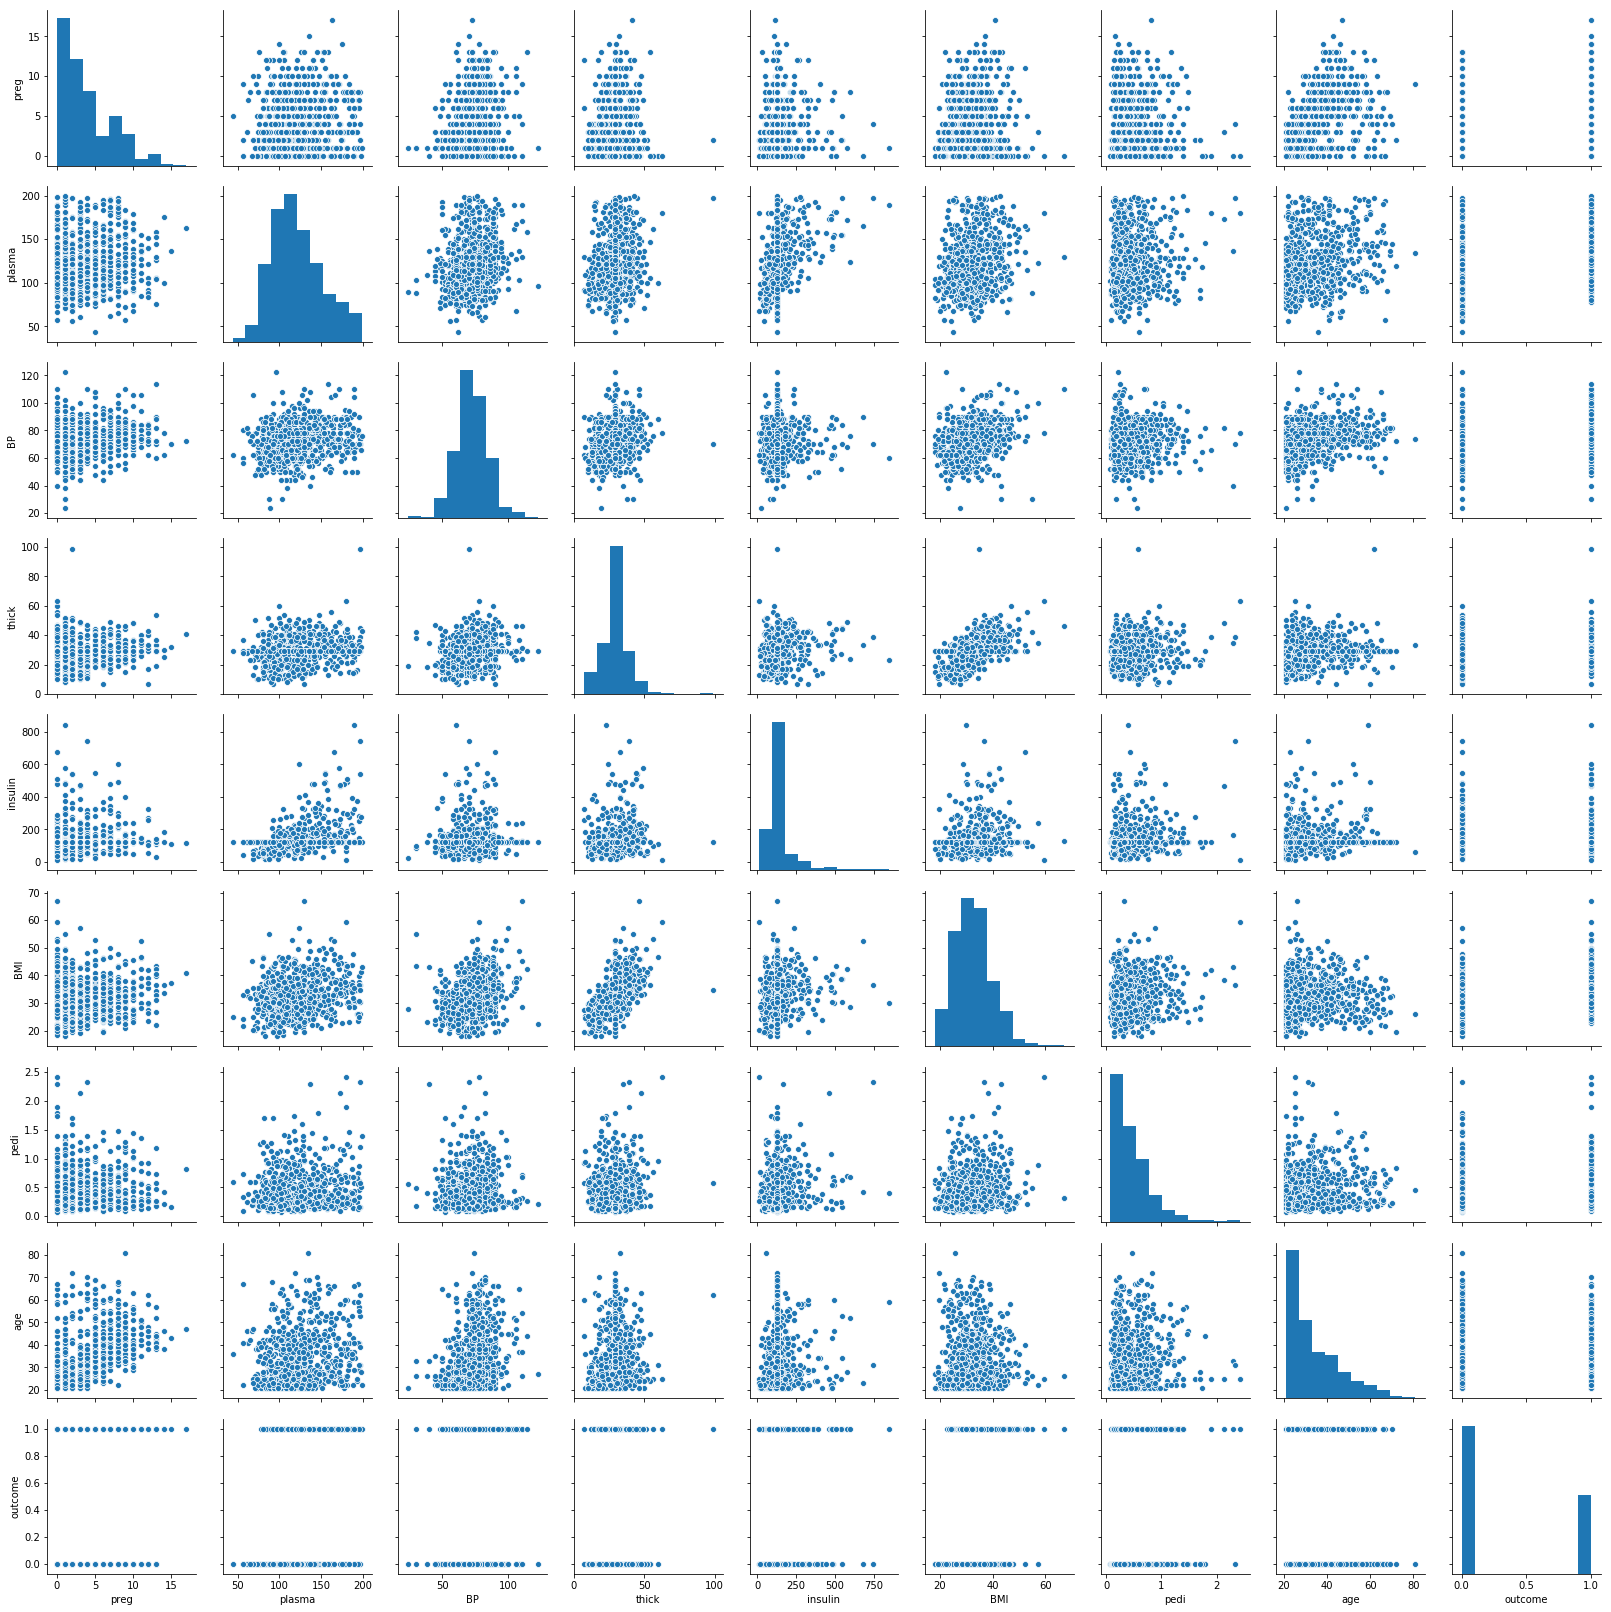

In [51]:
import seaborn as sns

# Pairplot using sns
sns.pairplot(pima_df)

Using the plot - infer the relationship between different variables

In [ ]:
# Observations :
# - some positive linear relationship between Age and BP
# - some positive relationship between BMI and thickness

In [95]:
pima_df.corr()

,preg,plasma,BP,thick,insulin,BMI,pedi,age,outcome
preg,1.000000,0.128213,0.208615,0.081770,0.025047,0.021559,-0.033523,0.544341,0.221898
plasma,0.128213,1.000000,0.218937,0.192615,0.419451,0.231049,0.137327,0.266909,0.492782
BP,0.208615,0.218937,1.000000,0.191892,0.045363,0.281257,-0.002378,0.324915,0.165723
thick,0.081770,0.192615,0.191892,1.000000,0.155610,0.543205,0.102188,0.126107,0.214873
insulin,0.025047,0.419451,0.045363,0.155610,1.000000,0.180241,0.126503,0.097101,0.203790
BMI,0.021559,0.231049,0.281257,0.543205,0.180241,1.000000,0.153438,0.025597,0.312038
pedi,-0.033523,0.137327,-0.002378,0.102188,0.126503,0.153438,1.000000,0.033561,0.173844
age,0.544341,0.266909,0.324915,0.126107,0.097101,0.025597,0.033561,1.000000,0.238356
outcome,0.221898,0.492782,0.165723,0.214873,0.203790,0.312038,0.173844,0.238356,1.000000


# Q8 Split the pima_df into training and test set in the ratio of 70:30 (Training:Test).</b>


In [53]:
# Prepare X and Y
X = pima_df.drop("outcome", axis=1)
y = pima_df["outcome"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=7)

# Q9 Create the decision tree model using “entropy” method of reducing the entropy and fit it to training data.</b>



In [72]:
from sklearn.tree import DecisionTreeClassifier

DTmodel =DecisionTreeClassifier(max_depth=4,criterion='entropy',random_state=0)
DTmodel.fit(X_train, y_train)

DecisionTreeClassifier(class_weight=None, criterion='entropy', max_depth=4,
            max_features=None, max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, presort=False, random_state=0,
            splitter='best')

# Q10 Print the accuracy of the model & print the confusion matrix 

In [73]:
# Calculate Accuracy of Model using Test data
ypredDT = model.predict(X_test)
accuracy = accuracy_score(y_test, ypredDT)
print(accuracy)

0.7316017316017316


In [74]:
# Print Confusion Matrix of Model using Test data
metrics.confusion_matrix(ypredDT,y_test)

array([[106,  21],
       [ 41,  63]], dtype=int64)

Print the feature importance of the decision model - Optional

In [65]:
print (pd.DataFrame(model.feature_importances_, columns = ["Imp"], index = X_train.columns))

              Imp
preg     0.000000
plasma   0.505836
BP       0.000000
thick    0.075503
insulin  0.014711
BMI      0.227769
pedi     0.029824
age      0.146357


# Q12 Apply the Random forest model and print the accuracy of Random forest Model

In [111]:
from sklearn.ensemble import RandomForestClassifier

RFmodel = RandomForestClassifier(n_estimators=50,criterion='entropy',random_state=0 )
RFmodel.fit(X_train, y_train)

RandomForestClassifier(bootstrap=True, class_weight=None, criterion='entropy',
            max_depth=None, max_features='auto', max_leaf_nodes=None,
            min_impurity_decrease=0.0, min_impurity_split=None,
            min_samples_leaf=1, min_samples_split=2,
            min_weight_fraction_leaf=0.0, n_estimators=50, n_jobs=None,
            oob_score=False, random_state=0, verbose=0, warm_start=False)

In [112]:
# Calculate Accuracy of Model using Test data
ypredRF = RFmodel.predict(X_test)
accuracy = accuracy_score(y_test, ypredRF)
print(accuracy)

0.7359307359307359


In [113]:
# Print Confusion Matrix of Model using Test data
metrics.confusion_matrix(ypredRF,y_test)

array([[125,  39],
       [ 22,  45]], dtype=int64)

# Q13 Apply Adaboost Ensemble Algorithm for the same data and print the accuracy.

In [114]:
from sklearn.ensemble import AdaBoostClassifier
boost_DT = AdaBoostClassifier(n_estimators=50,random_state=2)
boost_DT.fit(X_train, y_train)

AdaBoostClassifier(algorithm='SAMME.R', base_estimator=None,
          learning_rate=1.0, n_estimators=50, random_state=2)

In [115]:
# Calculate Accuracy of Model using Test data
ypredBDT = boost_DT.predict(X_test)
accuracy = accuracy_score(y_test, ypredBDT)
print(accuracy)

0.7489177489177489


# Q14 - Apply Bagging Classifier Algorithm and print the accuracy.

In [116]:
from sklearn.ensemble import BaggingClassifier
bag_DT = BaggingClassifier(n_estimators=30,random_state=2)
bag_DT.fit(X_train, y_train)

BaggingClassifier(base_estimator=None, bootstrap=True,
         bootstrap_features=False, max_features=1.0, max_samples=1.0,
         n_estimators=30, n_jobs=None, oob_score=False, random_state=2,
         verbose=0, warm_start=False)

In [117]:
# Calculate Accuracy of Model using Test data
ypredBDT = bag_DT.predict(X_test)
accuracy = accuracy_score(y_test, ypredBDT)
print(accuracy)

0.7402597402597403


# Q15 - Apply GradientBoost Classifier Algorithm for the same data and print the accuracy

In [90]:
from sklearn.ensemble import GradientBoostingClassifier
gb_model=GradientBoostingClassifier(n_estimators=30,random_state=2)

In [91]:
gb_model.fit(X_train, y_train)

GradientBoostingClassifier(criterion='friedman_mse', init=None,
              learning_rate=0.1, loss='deviance', max_depth=3,
              max_features=None, max_leaf_nodes=None,
              min_impurity_decrease=0.0, min_impurity_split=None,
              min_samples_leaf=1, min_samples_split=2,
              min_weight_fraction_leaf=0.0, n_estimators=30,
              n_iter_no_change=None, presort='auto', random_state=2,
              subsample=1.0, tol=0.0001, validation_fraction=0.1,
              verbose=0, warm_start=False)

In [118]:
# Calculate Accuracy of Model using Test data
ypredGB = gb_model.predict(X_test)
accuracy = accuracy_score(y_test, ypredGB)
print(accuracy)

0.7575757575757576


# Next steps are optional and will not be graded.

Voting is one of the simplest ways of combining the predictions from multiple machine learning algorithms.

It works by first creating two or more standalone models from your training dataset. A Voting Classifier can then be used to wrap your models and average the predictions of the sub-models when asked to make predictions for new data.

Apply Voting Classfier on the given dataset and state your insights.